Nombre: Jorge Abraham Fajardo López

Cuenta: 20231900189

# Proyecto: Clasificación de Flores con MobileNetV2

Entrenar un modelo con las clases:
- Daisy (Margarita)
- Dandelion (Diente de León)
- Rose (Rosa)
- Sunflower (Girasol)
- Tulip (Tulipán)

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [6]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# Ruta del dataset descargado de Kaggle
# Estructura esperada:
# dataset/
#   daisy/
#   dandelion/
#   rose/
#   sunflower/
#   tulip/
DATA_DIR = 'C:\\Users\\HTS\\Desktop\\Proyecto_clasificador_flores\\dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print('Clases detectadas:', class_names)
print('Total clases:', len(class_names))

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Clases detectadas: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total clases: 5


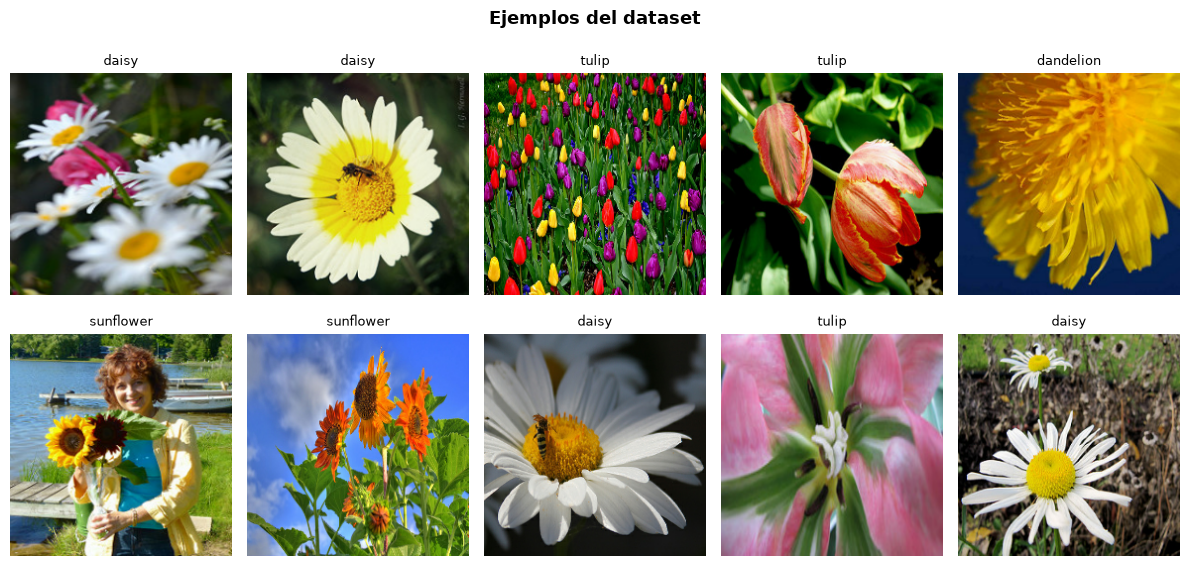

In [7]:
# Mostrar ejemplos del dataset
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle('Ejemplos del dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Preprocesamiento para MobileNetV2
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

## Construcción del modelo con Transfer Learning

Se utiliza MobileNetV2 preentrenada en ImageNet como base. Sus pesos se congelan (`trainable=False`) para aprovechar las características ya aprendidas. Se agregan capas personalizadas para clasificar las 5 categorías de flores.

In [9]:
NUM_CLASES = len(class_names)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenamiento

`EarlyStopping` detiene el entrenamiento automáticamente cuando la pérdida de validación deja de mejorar, evitando sobreajuste.

In [10]:
EPOCHS = 10

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10


c:\Users\HTS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


108/108 ━━━━━━━━━━━━━━━━━━━━ 61s 503ms/step - accuracy: 0.7041 - loss: 0.8032 - val_accuracy: 0.8413 - val_loss: 0.4704
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 52s 480ms/step - accuracy: 0.8561 - loss: 0.4202 - val_accuracy: 0.8772 - val_loss: 0.3773
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 52s 479ms/step - accuracy: 0.8877 - loss: 0.3454 - val_accuracy: 0.8737 - val_loss: 0.3442
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 51s 474ms/step - accuracy: 0.9050 - loss: 0.2951 - val_accuracy: 0.8760 - val_loss: 0.3347
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 53s 487ms/step - accuracy: 0.9108 - loss: 0.2709 - val_accuracy: 0.8795 - val_loss: 0.3267
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 54s 496ms/step - accuracy: 0.9241 - loss: 0.2439 - val_accuracy: 0.8864 - val_loss: 0.3083
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 54s 499ms/step - accuracy: 0.9233 - loss: 0.2252 - val_accuracy: 0.8795 - val_loss: 0.3154
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 81s 491ms/step - accuracy: 0.9314 - loss: 0.2073 - val

In [11]:
# Evaluación en validación
loss, acc = model.evaluate(val_ds, verbose=0)
print(f'Loss:     {loss:.4f}')
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Loss:     0.3083
Accuracy: 0.8864 (88.64%)


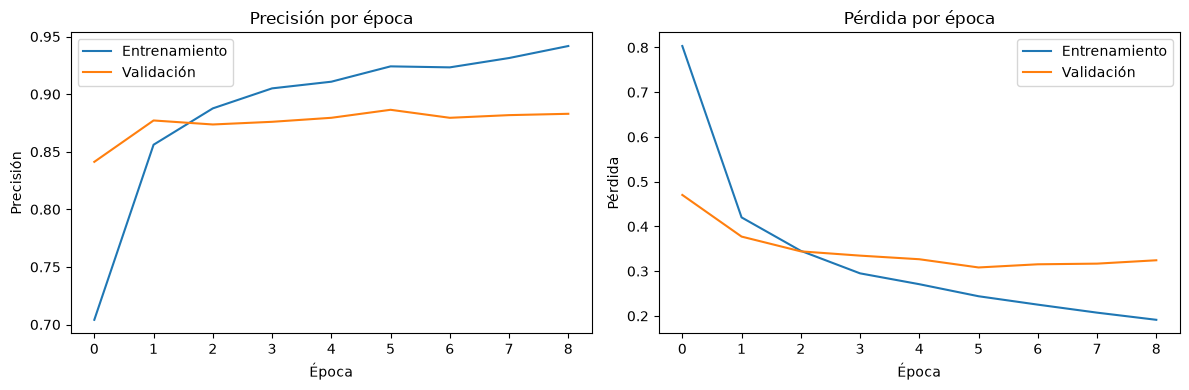

In [12]:
# Gráficas de precisión y pérdida
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Precisión por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()

ax2.plot(history.history['loss'],     label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()

plt.tight_layout()
plt.show()

## Métricas de evaluación

Se genera el reporte de clasificación con precisión, recall y F1-score por clase, junto con la matriz de confusión.

In [13]:
# Reporte de clasificación
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       daisy       0.89      0.88      0.88       144
   dandelion       0.92      0.88      0.90       206
        rose       0.80      0.90      0.85       137
   sunflower       0.88      0.91      0.90       172
       tulip       0.92      0.87      0.90       204

    accuracy                           0.89       863
   macro avg       0.88      0.89      0.88       863
weighted avg       0.89      0.89      0.89       863



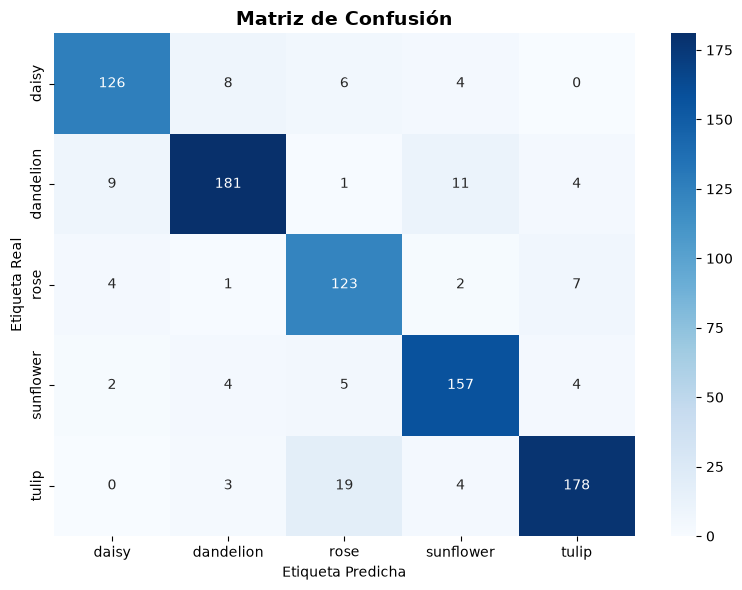

In [14]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

In [15]:
# Guardar el modelo y las clases
model.save('modelo_flores.keras')
model.save('modelo_flores.h5')

with open('clases.json', 'w') as f:
    json.dump(class_names, f)

print('Modelo guardado como modelo_flores.keras')
print('Modelo guardado como modelo_flores.h5')
print('Clases guardadas como clases.json')

Modelo guardado como modelo_flores.keras
Modelo guardado como modelo_flores.h5
Clases guardadas como clases.json


## Prueba con imágenes nuevas

Descarga imágenes de flores de internet, colócalas en la carpeta del proyecto y prueba la clasificación.

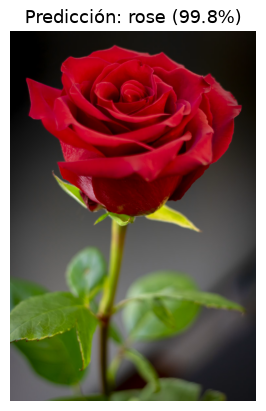

Resultado: rose con 99.8% de confianza


In [16]:
def clasificar_imagen(ruta_imagen):
    img       = tf.keras.utils.load_img(ruta_imagen, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = preprocess_input(tf.cast(img_array, tf.float32))
    img_array = tf.expand_dims(img_array, axis=0)

    prediccion = model.predict(img_array, verbose=0)
    clase      = class_names[np.argmax(prediccion)]
    confianza  = np.max(prediccion) * 100

    plt.imshow(tf.keras.utils.load_img(ruta_imagen))
    plt.title(f'Predicción: {clase} ({confianza:.1f}%)', fontsize=13)
    plt.axis('off')
    plt.show()

    print(f'Resultado: {clase} con {confianza:.1f}% de confianza')


# Cambia la ruta por tu imagen de prueba
clasificar_imagen('prueba.jpg')